# Clue Utilization & Early Termination Rate Analysis

## Objective
Compute and analyze two key collaboration metrics:
1. **Clue Utilization**: ratio of correct guesses to the specified clue number `n`
2. **Early Termination Rate**: proportion of turns where Guessers yield before exhausting allowed guesses

## Data Source
- `game_logs/`: Raw game results from persona pairs

## Configuration
- **MAX_PERSONA_ID**: Configurable limit to match experiment settings
- **LOGS_DIR**: Directory containing game log files

## 1. Setup and Imports

In [1]:
import json
import os
import glob
import re
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_ind, mannwhitneyu

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ===== CONFIGURATION =====
MAX_PERSONA_ID = 10  # Set to match your experiment configuration
LOGS_DIR = 'game_logs/gemma2 - full'  # Directory containing game logs
print(f"Analysis configured for personas 1-{MAX_PERSONA_ID}")
print(f"Loading logs from: {LOGS_DIR}")

Analysis configured for personas 1-10
Loading logs from: game_logs/gemma2 - full


## 2. Load and Parse Game Logs

In [2]:
def parse_game_filename(filename):
    """
    Extract codemaster and guesser persona IDs from filename.
    Pattern: full_persona_exp_TIMESTAMP_cm{X}_g{Y}_game{N}.json
    Returns: (codemaster_id, guesser_id, game_number)
    """
    pattern = r'cm([^_]+)_g([^_]+)_game(\d+)\.json'
    match = re.search(pattern, filename)
    if match:
        cm_id = match.group(1)  # Could be 'None' or a number
        g_id = match.group(2)
        game_num = int(match.group(3))
        
        # Convert to int if not 'None'
        cm_id = None if cm_id == 'None' else int(cm_id)
        g_id = None if g_id == 'None' else int(g_id)
        
        return cm_id, g_id, game_num
    return None, None, None

In [3]:
def load_game_logs_with_turns(logs_dir, max_persona_id=None):
    """
    Load all game logs with full turn-level data.
    
    Returns:
        games_df: DataFrame with game-level info
        turns_df: DataFrame with turn-level info
    """
    game_records = []
    turn_records = []
    
    log_files = glob.glob(os.path.join(logs_dir, '*.json'))
    print(f"Found {len(log_files)} game log files")
    
    filtered_count = 0
    parsing_errors = 0
    
    for log_file in log_files:
        filename = os.path.basename(log_file)
        cm_id, g_id, game_num = parse_game_filename(filename)
        
        if cm_id is None and g_id is None and game_num is None:
            parsing_errors += 1
            continue
        
        # Filter by max_persona_id if specified
        if max_persona_id is not None:
            if (cm_id is not None and cm_id > max_persona_id) or (g_id is not None and g_id > max_persona_id):
                filtered_count += 1
                continue
        
        try:
            with open(log_file, 'r') as f:
                data = json.load(f)
            
            game_id = f"{cm_id}_{g_id}_{game_num}"
            
            # Game-level record
            game_records.append({
                'game_id': game_id,
                'cm_id': cm_id,
                'guesser_id': g_id,
                'game_num': game_num,
                'won': data.get('won', False),
                'total_turns': data.get('total_turns', 0),
                'end_reason': data.get('end_reason', 'unknown'),
                'duration': data.get('game_duration', 0)
            })
            
            # Turn-level records
            for turn in data.get('turns', []):
                clue_number = turn.get('clue_number', 0)
                results = turn.get('results', [])
                guesses = turn.get('guesses', [])
                
                correct_guesses = sum(1 for r in results if r == 'team word')
                
                # Get collaboration signals
                collab = turn.get('collaboration_signals', {})
                turn_ended_early = collab.get('turn_ended_early', False)
                
                # Compute clue utilization
                clue_utilization = correct_guesses / clue_number if clue_number > 0 else 0
                
                # Determine turn outcome
                turn_outcome = 'neutral'
                if 'assassin' in results:
                    turn_outcome = 'assassin'
                elif results and results[-1] == 'team word':
                    turn_outcome = 'all_correct'
                elif 'neutral' in results:
                    turn_outcome = 'neutral'
                
                turn_records.append({
                    'game_id': game_id,
                    'cm_id': cm_id,
                    'guesser_id': g_id,
                    'turn_number': turn.get('turn_number', 0),
                    'clue_word': turn.get('clue_word', ''),
                    'clue_number': clue_number,
                    'num_guesses': len(guesses),
                    'correct_guesses': correct_guesses,
                    'clue_utilization': clue_utilization,
                    'turn_ended_early': turn_ended_early,
                    'turn_outcome': turn_outcome,
                    'turn_efficiency': turn.get('turn_efficiency', clue_utilization)
                })
                
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            continue
    
    games_df = pd.DataFrame(game_records)
    turns_df = pd.DataFrame(turn_records)
    
    print(f"\nLoaded {len(games_df)} games, {len(turns_df)} turns")
    if parsing_errors > 0:
        print(f"Skipped {parsing_errors} files due to parsing errors")
    if filtered_count > 0:
        print(f"Filtered out {filtered_count} games with persona IDs > {max_persona_id}")
    
    return games_df, turns_df


# Load data
games_df, turns_df = load_game_logs_with_turns(LOGS_DIR, MAX_PERSONA_ID)
print(f"\nGames shape: {games_df.shape}")
print(f"Turns shape: {turns_df.shape}")
turns_df.head(10)

Found 121 game log files

Loaded 121 games, 888 turns

Games shape: (121, 8)
Turns shape: (888, 12)


,game_id,cm_id,guesser_id,turn_number,clue_word,clue_number,num_guesses,correct_guesses,clue_utilization,turn_ended_early,turn_outcome,turn_efficiency
0,2_4_0,2.0,4.0,1,STORAGE,3,2,1,0.333333,True,neutral,0.5
1,2_4_0,2.0,4.0,2,COLD,3,2,1,0.333333,True,neutral,0.5
2,2_4_0,2.0,4.0,3,MYSTERY,2,3,3,1.500000,False,all_correct,1.0
3,2_4_0,2.0,4.0,4,GARBAGE,2,2,1,0.500000,False,neutral,0.5
4,2_4_0,2.0,4.0,5,AMERICAN,2,2,1,0.500000,False,neutral,0.5
5,2_4_0,2.0,4.0,6,POWER,2,1,0,0.000000,True,neutral,0.0
6,2_4_0,2.0,4.0,7,PLAY,2,2,1,0.500000,False,neutral,0.5
7,2_4_0,2.0,4.0,8,WING,1,1,1,1.000000,False,all_correct,1.0
8,10_8_0,10.0,8.0,1,TOOL,4,1,0,0.000000,True,neutral,0.0
9,10_8_0,10.0,8.0,2,WORK,3,1,0,0.000000,True,neutral,0.0


## 3. Clue Utilization Analysis

**Definition**: Clue utilization = correct guesses / clue number (n)

This metric measures how effectively the Guesser converts the Codemaster's clues into correct guesses.

In [4]:
# Overall clue utilization statistics
print("=== Clue Utilization Statistics (Per Turn) ===")
print(f"Mean: {turns_df['clue_utilization'].mean():.4f}")
print(f"Median: {turns_df['clue_utilization'].median():.4f}")
print(f"Std: {turns_df['clue_utilization'].std():.4f}")
print(f"Min: {turns_df['clue_utilization'].min():.4f}")
print(f"Max: {turns_df['clue_utilization'].max():.4f}")

# Distribution of clue numbers
print(f"\n=== Clue Number Distribution ===")
print(turns_df['clue_number'].value_counts().sort_index())

=== Clue Utilization Statistics (Per Turn) ===
Mean: 0.3720
Median: 0.3333
Std: 0.3691
Min: 0.0000
Max: 1.5000

=== Clue Number Distribution ===
clue_number
0     35
1     57
2    345
3    356
4     74
5     14
6      5
7      1
8      1
Name: count, dtype: int64


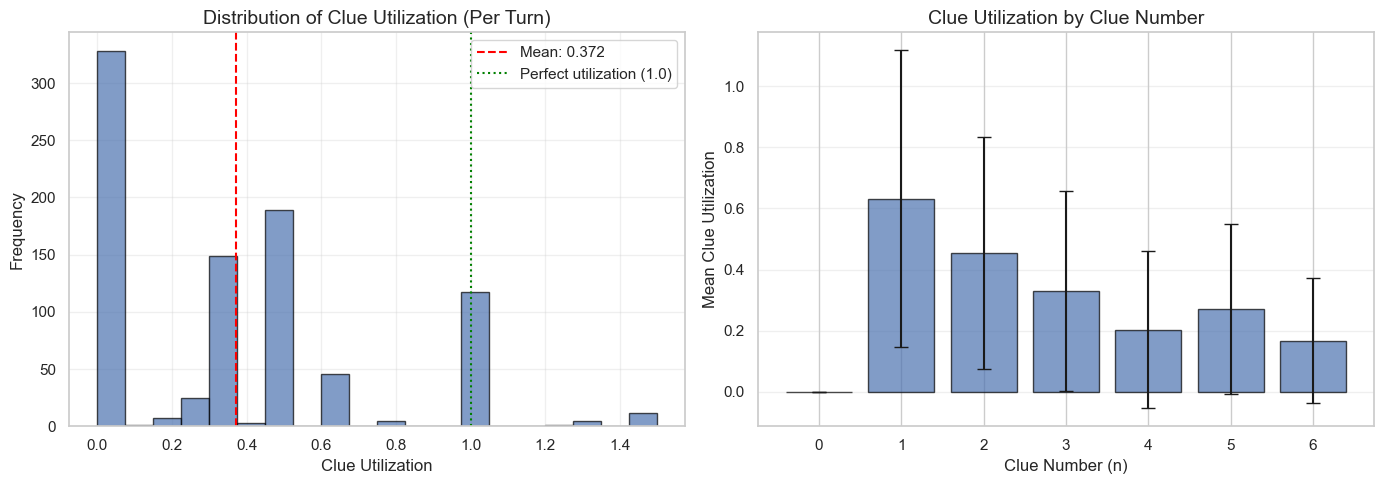

In [5]:
# Histogram of clue utilization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of clue utilization
ax1 = axes[0]
ax1.hist(turns_df['clue_utilization'], bins=20, edgecolor='black', alpha=0.7)
ax1.axvline(turns_df['clue_utilization'].mean(), color='red', linestyle='--', 
            label=f"Mean: {turns_df['clue_utilization'].mean():.3f}")
ax1.axvline(1.0, color='green', linestyle=':', label='Perfect utilization (1.0)')
ax1.set_xlabel('Clue Utilization', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Clue Utilization (Per Turn)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Clue utilization by clue number
ax2 = axes[1]
clue_util_by_n = turns_df.groupby('clue_number')['clue_utilization'].agg(['mean', 'std', 'count'])
clue_util_by_n = clue_util_by_n[clue_util_by_n['count'] >= 5]  # Filter low counts
ax2.bar(clue_util_by_n.index, clue_util_by_n['mean'], yerr=clue_util_by_n['std'], 
        capsize=5, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Clue Number (n)', fontsize=12)
ax2.set_ylabel('Mean Clue Utilization', fontsize=12)
ax2.set_title('Clue Utilization by Clue Number', fontsize=14)
ax2.set_xticks(clue_util_by_n.index)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/clue_utilization_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Aggregate clue utilization by persona pair
# Filter to only include pairs where both have personas
turns_with_personas = turns_df[
    (turns_df['cm_id'].notna()) & (turns_df['guesser_id'].notna())
].copy()

clue_util_by_pair = turns_with_personas.groupby(['cm_id', 'guesser_id']).agg({
    'clue_utilization': ['mean', 'std', 'count'],
    'correct_guesses': 'sum',
    'clue_number': 'sum'
}).reset_index()

clue_util_by_pair.columns = ['cm_id', 'guesser_id', 'mean_clue_util', 'std_clue_util', 
                             'num_turns', 'total_correct', 'total_clue_numbers']

# Add aggregate efficiency (total correct / total clue numbers)
clue_util_by_pair['aggregate_efficiency'] = (
    clue_util_by_pair['total_correct'] / clue_util_by_pair['total_clue_numbers']
)

# Add same persona flag
clue_util_by_pair['is_same_persona'] = clue_util_by_pair['cm_id'] == clue_util_by_pair['guesser_id']

print(f"Aggregated clue utilization for {len(clue_util_by_pair)} persona pairs")
clue_util_by_pair.sort_values('mean_clue_util', ascending=False).head(10)

Aggregated clue utilization for 100 persona pairs


,cm_id,guesser_id,mean_clue_util,std_clue_util,num_turns,total_correct,total_clue_numbers,aggregate_efficiency,is_same_persona
11,2.0,2.0,0.750000,0.273861,6,9,12,0.750000,True
77,8.0,8.0,0.750000,0.645497,4,7,10,0.700000,True
57,6.0,8.0,0.722222,0.544331,6,9,14,0.642857,False
49,5.0,10.0,0.722222,0.544331,6,9,12,0.750000,False
92,10.0,3.0,0.666667,NaN,1,2,3,0.666667,False
80,9.0,1.0,0.666667,0.272166,4,8,12,0.666667,False
89,9.0,10.0,0.666667,0.471405,5,9,14,0.642857,False
6,1.0,7.0,0.666667,0.408248,5,9,14,0.642857,False
51,6.0,2.0,0.666667,0.278887,6,9,14,0.642857,False
70,8.0,1.0,0.638889,0.531420,6,8,12,0.666667,False


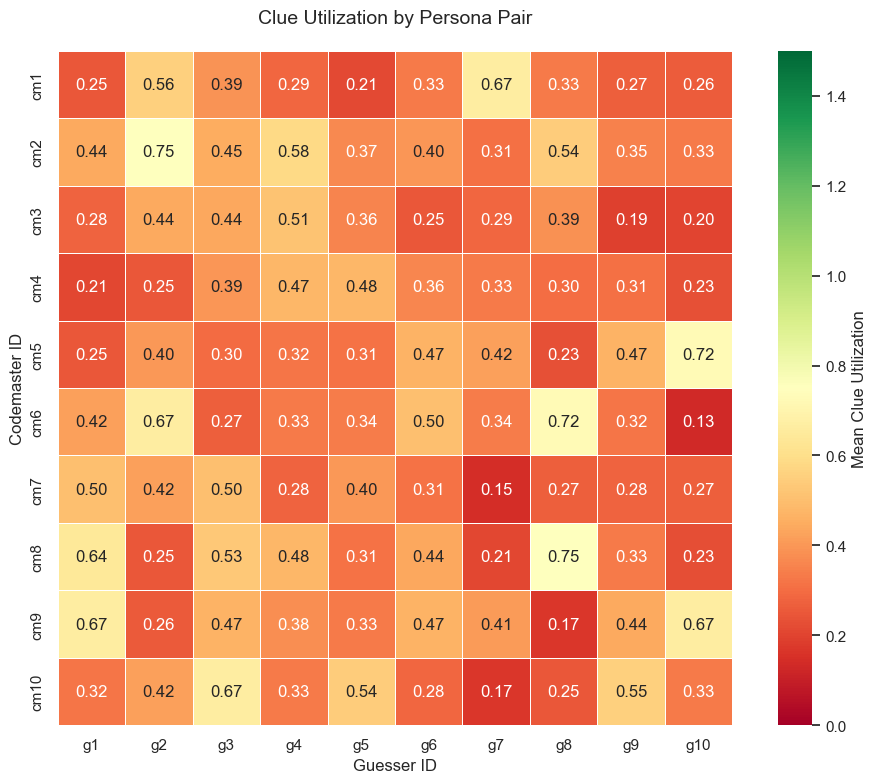

In [7]:
# Create heatmap of clue utilization by persona pair
persona_ids = sorted(turns_with_personas['cm_id'].dropna().unique())
n_personas = len(persona_ids)

clue_util_matrix = np.full((n_personas, n_personas), np.nan)
for _, row in clue_util_by_pair.iterrows():
    i = int(row['cm_id']) - 1
    j = int(row['guesser_id']) - 1
    if 0 <= i < n_personas and 0 <= j < n_personas:
        clue_util_matrix[i, j] = row['mean_clue_util']

clue_util_heatmap_df = pd.DataFrame(
    clue_util_matrix,
    index=[f'cm{i}' for i in range(1, n_personas + 1)],
    columns=[f'g{i}' for i in range(1, n_personas + 1)]
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    clue_util_heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1.5,
    cbar_kws={'label': 'Mean Clue Utilization'},
    square=True,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Clue Utilization by Persona Pair', fontsize=14, pad=20)
plt.xlabel('Guesser ID', fontsize=12)
plt.ylabel('Codemaster ID', fontsize=12)
plt.tight_layout()
plt.savefig('figures/clue_utilization_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. Early Termination Rate Analysis

**Definition**: Proportion of turns where the Guesser yields before exhausting allowed guesses (n+1).

This metric serves as a proxy for calibrated confidence - Guessers who stop early may have better uncertainty estimation.

In [8]:
# Overall early termination statistics
print("=== Early Termination Statistics ===")
total_turns = len(turns_df)
early_term_turns = turns_df['turn_ended_early'].sum()
early_term_rate = early_term_turns / total_turns

print(f"Total turns: {total_turns}")
print(f"Turns ended early: {early_term_turns}")
print(f"Early termination rate: {early_term_rate:.4f} ({early_term_rate*100:.1f}%)")

# Breakdown by turn outcome
print(f"\n=== Early Termination by Turn Outcome ===")
early_term_by_outcome = turns_df.groupby('turn_outcome')['turn_ended_early'].agg(['sum', 'count', 'mean'])
early_term_by_outcome.columns = ['early_term_count', 'total_count', 'early_term_rate']
print(early_term_by_outcome)

=== Early Termination Statistics ===
Total turns: 888
Turns ended early: 467
Early termination rate: 0.5259 (52.6%)

=== Early Termination by Turn Outcome ===
              early_term_count  total_count  early_term_rate
turn_outcome                                                
all_correct                  0           66         0.000000
assassin                    40           76         0.526316
neutral                    427          746         0.572386


In [9]:
# Aggregate early termination rate by persona pair
early_term_by_pair = turns_with_personas.groupby(['cm_id', 'guesser_id']).agg({
    'turn_ended_early': ['sum', 'count', 'mean']
}).reset_index()

early_term_by_pair.columns = ['cm_id', 'guesser_id', 'early_term_count', 
                               'total_turns', 'early_term_rate']

# Add same persona flag
early_term_by_pair['is_same_persona'] = early_term_by_pair['cm_id'] == early_term_by_pair['guesser_id']

print(f"Aggregated early termination for {len(early_term_by_pair)} persona pairs")
early_term_by_pair.sort_values('early_term_rate', ascending=False).head(10)

Aggregated early termination for 100 persona pairs


,cm_id,guesser_id,early_term_count,total_turns,early_term_rate,is_same_persona
55,6.0,6.0,1,1,1.000000,True
96,10.0,7.0,2,2,1.000000,False
84,9.0,5.0,2,2,1.000000,False
25,3.0,6.0,1,1,1.000000,False
66,7.0,7.0,4,4,1.000000,True
59,6.0,10.0,11,12,0.916667,False
4,1.0,5.0,8,9,0.888889,False
30,4.0,1.0,7,8,0.875000,False
29,3.0,10.0,13,15,0.866667,False
87,9.0,8.0,6,7,0.857143,False


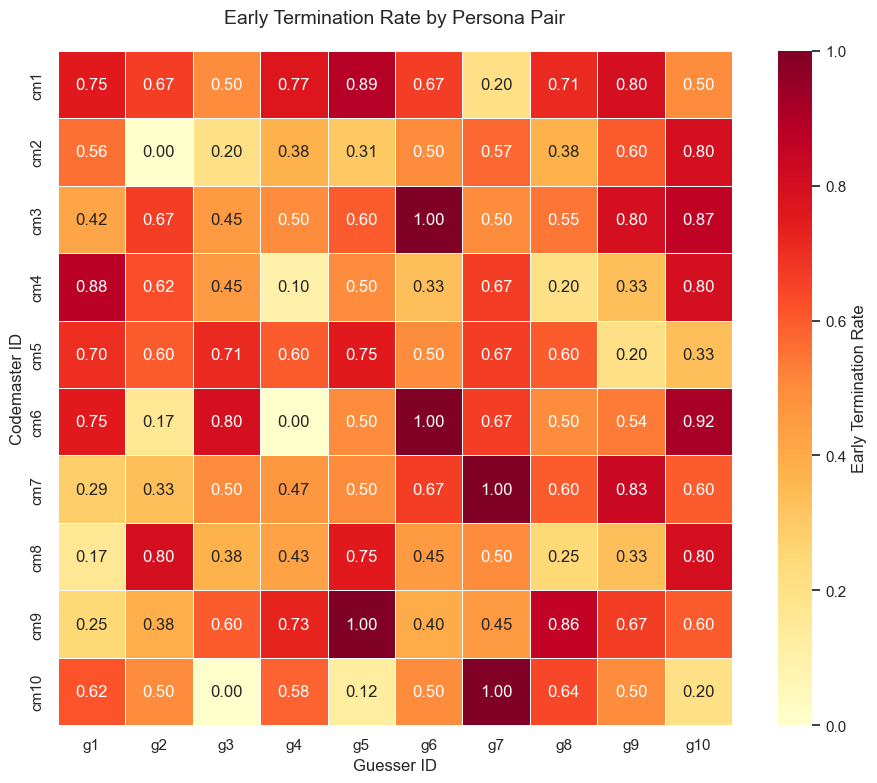

In [10]:
# Create heatmap of early termination rate by persona pair
early_term_matrix = np.full((n_personas, n_personas), np.nan)
for _, row in early_term_by_pair.iterrows():
    i = int(row['cm_id']) - 1
    j = int(row['guesser_id']) - 1
    if 0 <= i < n_personas and 0 <= j < n_personas:
        early_term_matrix[i, j] = row['early_term_rate']

early_term_heatmap_df = pd.DataFrame(
    early_term_matrix,
    index=[f'cm{i}' for i in range(1, n_personas + 1)],
    columns=[f'g{i}' for i in range(1, n_personas + 1)]
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    early_term_heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Early Termination Rate'},
    square=True,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Early Termination Rate by Persona Pair', fontsize=14, pad=20)
plt.xlabel('Guesser ID', fontsize=12)
plt.ylabel('Codemaster ID', fontsize=12)
plt.tight_layout()
plt.savefig('figures/early_termination_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

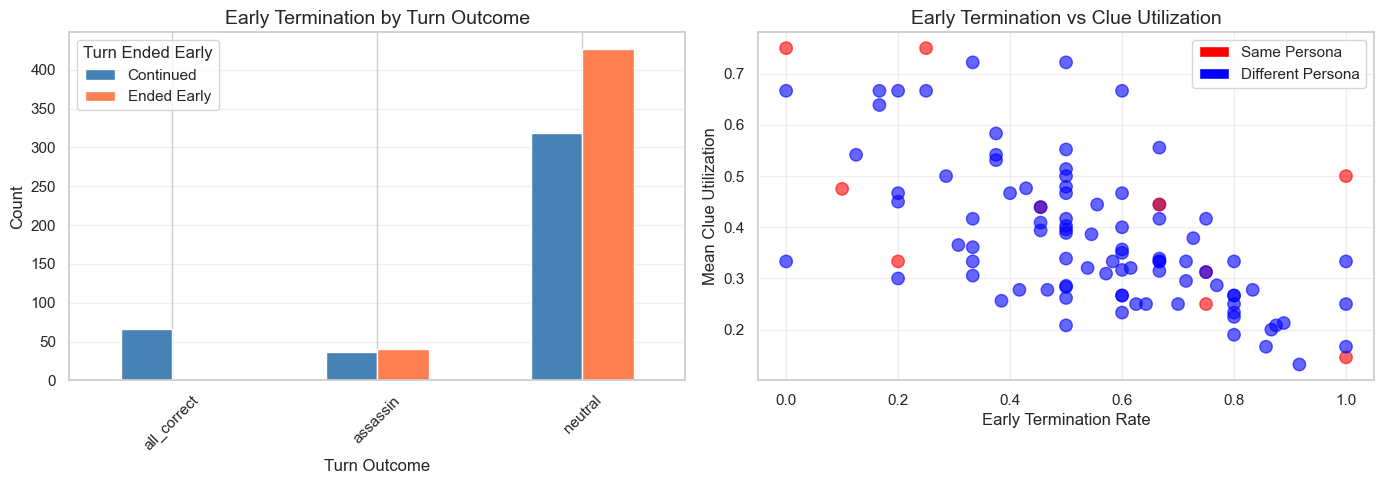

In [11]:
# Visualization: Early termination vs clue utilization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of early termination by turn outcome
ax1 = axes[0]
outcome_counts = turns_df.groupby(['turn_outcome', 'turn_ended_early']).size().unstack(fill_value=0)
outcome_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_xlabel('Turn Outcome', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Early Termination by Turn Outcome', fontsize=14)
ax1.legend(['Continued', 'Ended Early'], title='Turn Ended Early')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Scatter: Early termination rate vs clue utilization (per persona pair)
ax2 = axes[1]
merged_pair_data = pd.merge(
    clue_util_by_pair[['cm_id', 'guesser_id', 'mean_clue_util', 'is_same_persona']],
    early_term_by_pair[['cm_id', 'guesser_id', 'early_term_rate']],
    on=['cm_id', 'guesser_id']
)

colors = merged_pair_data['is_same_persona'].map({True: 'red', False: 'blue'})
ax2.scatter(merged_pair_data['early_term_rate'], merged_pair_data['mean_clue_util'], 
            c=colors, alpha=0.6, s=80)
ax2.set_xlabel('Early Termination Rate', fontsize=12)
ax2.set_ylabel('Mean Clue Utilization', fontsize=12)
ax2.set_title('Early Termination vs Clue Utilization', fontsize=14)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Same Persona'),
                   Patch(facecolor='blue', label='Different Persona')]
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/early_termination_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

Test relationships between metrics and game outcomes.

In [12]:
# Aggregate game-level metrics
game_metrics = games_df[
    (games_df['cm_id'].notna()) & (games_df['guesser_id'].notna())
].copy()

# Aggregate turn metrics per game
turn_agg = turns_with_personas.groupby('game_id').agg({
    'clue_utilization': 'mean',
    'turn_ended_early': 'mean',  # This gives the rate
    'correct_guesses': 'sum',
    'clue_number': 'sum'
}).reset_index()
turn_agg.columns = ['game_id', 'game_clue_util', 'game_early_term_rate', 
                    'total_correct', 'total_clue_numbers']

# Merge with game outcomes
game_analysis = pd.merge(game_metrics, turn_agg, on='game_id', how='left')
game_analysis['is_same_persona'] = game_analysis['cm_id'] == game_analysis['guesser_id']

print(f"Games with metrics: {len(game_analysis)}")
game_analysis.head()

Games with metrics: 100


,game_id,cm_id,guesser_id,game_num,won,total_turns,end_reason,duration,game_clue_util,game_early_term_rate,total_correct,total_clue_numbers,is_same_persona
0,2_4_0,2.0,4.0,0,True,8,all_found,170.235416,0.583333,0.375000,9,17,False
1,10_8_0,10.0,8.0,0,False,14,assassin,406.068873,0.250000,0.642857,8,35,False
2,3_7_0,3.0,7.0,0,True,14,all_found,201.709754,0.285714,0.500000,9,33,False
3,5_10_0,5.0,10.0,0,True,6,all_found,248.146291,0.722222,0.333333,9,12,False
4,8_3_0,8.0,3.0,0,True,8,all_found,298.797989,0.531250,0.375000,9,20,False


In [13]:
def compute_correlation(df, x_col, y_col, label=""):
    """Compute Pearson and Spearman correlations with p-values."""
    valid_data = df[[x_col, y_col]].dropna()
    
    if len(valid_data) < 3:
        print(f"Insufficient data for correlation: {label}")
        return None
    
    x = valid_data[x_col]
    y = valid_data[y_col]
    
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"Sample size: {len(valid_data)}")
    print(f"Pearson:  r = {pearson_r:+.4f}, p = {pearson_p:.4f} {'***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else '(n.s.)'}")
    print(f"Spearman: ρ = {spearman_r:+.4f}, p = {spearman_p:.4f} {'***' if spearman_p < 0.001 else '**' if spearman_p < 0.01 else '*' if spearman_p < 0.05 else '(n.s.)'}")
    
    return {'x': x_col, 'y': y_col, 'n': len(valid_data), 
            'pearson_r': pearson_r, 'pearson_p': pearson_p,
            'spearman_r': spearman_r, 'spearman_p': spearman_p}

# Convert 'won' to numeric
game_analysis['won_numeric'] = game_analysis['won'].astype(int)

# Correlation: Clue utilization vs Win
corr1 = compute_correlation(game_analysis, 'game_clue_util', 'won_numeric', 
                            "Clue Utilization → Win")

# Correlation: Early termination rate vs Win
corr2 = compute_correlation(game_analysis, 'game_early_term_rate', 'won_numeric',
                            "Early Termination Rate → Win")

# Correlation: Clue utilization vs Total turns (efficiency)
corr3 = compute_correlation(game_analysis, 'game_clue_util', 'total_turns',
                            "Clue Utilization → Total Turns")

# Correlation: Early termination vs Clue utilization
corr4 = compute_correlation(game_analysis, 'game_early_term_rate', 'game_clue_util',
                            "Early Termination Rate ↔ Clue Utilization")


Clue Utilization → Win
Sample size: 100
Pearson:  r = +0.3756, p = 0.0001 ***
Spearman: ρ = +0.4083, p = 0.0000 ***

Early Termination Rate → Win
Sample size: 100
Pearson:  r = -0.3526, p = 0.0003 ***
Spearman: ρ = -0.3835, p = 0.0001 ***

Clue Utilization → Total Turns
Sample size: 100
Pearson:  r = -0.2886, p = 0.0036 **
Spearman: ρ = -0.2388, p = 0.0167 *

Early Termination Rate ↔ Clue Utilization
Sample size: 100
Pearson:  r = -0.6177, p = 0.0000 ***
Spearman: ρ = -0.6169, p = 0.0000 ***


In [14]:
# Compare same persona vs different persona pairs
print("\n" + "="*60)
print("SAME vs DIFFERENT PERSONA COMPARISON")
print("="*60)

same_persona = game_analysis[game_analysis['is_same_persona'] == True]
diff_persona = game_analysis[game_analysis['is_same_persona'] == False]

print(f"\nSame Persona Games (n={len(same_persona)}):")
print(f"  Win Rate: {same_persona['won'].mean():.3f}")
print(f"  Clue Utilization: {same_persona['game_clue_util'].mean():.3f} ± {same_persona['game_clue_util'].std():.3f}")
print(f"  Early Term Rate: {same_persona['game_early_term_rate'].mean():.3f} ± {same_persona['game_early_term_rate'].std():.3f}")

print(f"\nDifferent Persona Games (n={len(diff_persona)}):")
print(f"  Win Rate: {diff_persona['won'].mean():.3f}")
print(f"  Clue Utilization: {diff_persona['game_clue_util'].mean():.3f} ± {diff_persona['game_clue_util'].std():.3f}")
print(f"  Early Term Rate: {diff_persona['game_early_term_rate'].mean():.3f} ± {diff_persona['game_early_term_rate'].std():.3f}")

# Statistical tests
if len(same_persona) > 0 and len(diff_persona) > 0:
    t_clue, p_clue = ttest_ind(same_persona['game_clue_util'].dropna(), 
                                diff_persona['game_clue_util'].dropna())
    t_early, p_early = ttest_ind(same_persona['game_early_term_rate'].dropna(),
                                  diff_persona['game_early_term_rate'].dropna())
    
    print(f"\nt-test (Clue Utilization): t={t_clue:.3f}, p={p_clue:.4f}")
    print(f"t-test (Early Term Rate): t={t_early:.3f}, p={p_early:.4f}")


SAME vs DIFFERENT PERSONA COMPARISON

Same Persona Games (n=10):
  Win Rate: 0.400
  Clue Utilization: 0.440 ± 0.196
  Early Term Rate: 0.517 ± 0.367

Different Persona Games (n=90):
  Win Rate: 0.389
  Clue Utilization: 0.377 ± 0.137
  Early Term Rate: 0.551 ± 0.220

t-test (Clue Utilization): t=1.317, p=0.1910
t-test (Early Term Rate): t=-0.424, p=0.6728


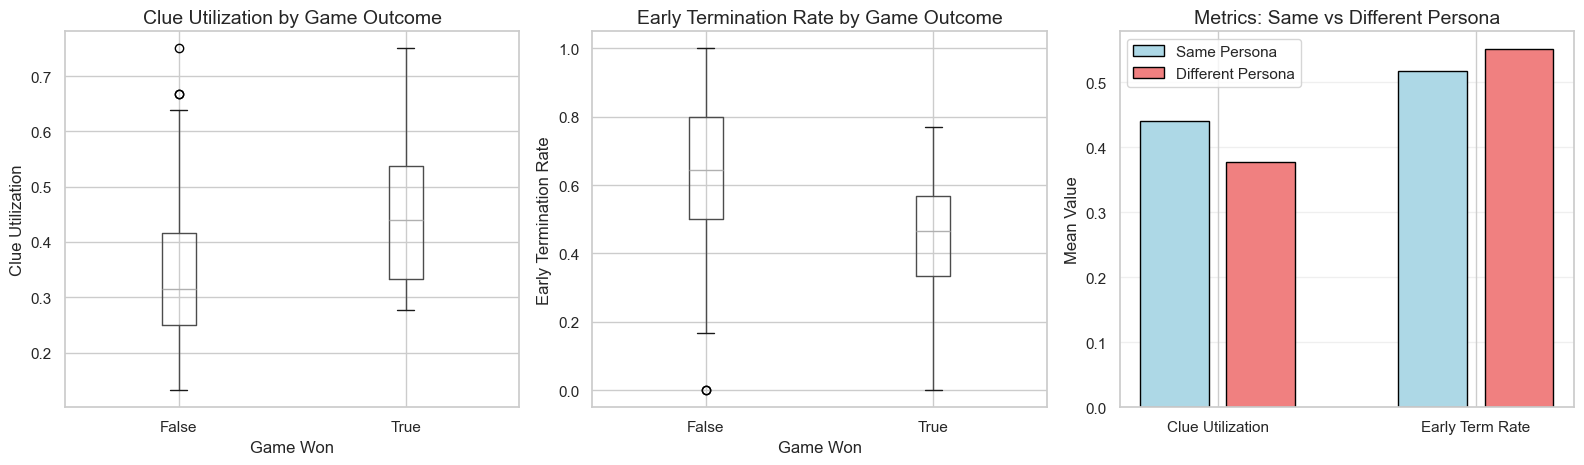

In [15]:
# Visualization: Scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Clue utilization by win/loss
ax1 = axes[0]
game_analysis.boxplot(column='game_clue_util', by='won', ax=ax1)
ax1.set_xlabel('Game Won', fontsize=12)
ax1.set_ylabel('Clue Utilization', fontsize=12)
ax1.set_title('Clue Utilization by Game Outcome', fontsize=14)
plt.suptitle('')  # Remove automatic title

# Plot 2: Early termination rate by win/loss
ax2 = axes[1]
game_analysis.boxplot(column='game_early_term_rate', by='won', ax=ax2)
ax2.set_xlabel('Game Won', fontsize=12)
ax2.set_ylabel('Early Termination Rate', fontsize=12)
ax2.set_title('Early Termination Rate by Game Outcome', fontsize=14)
plt.suptitle('')

# Plot 3: Comparison by persona type
ax3 = axes[2]
metrics_comparison = pd.DataFrame({
    'Clue Util (Same)': [same_persona['game_clue_util'].mean()],
    'Clue Util (Diff)': [diff_persona['game_clue_util'].mean()],
    'Early Term (Same)': [same_persona['game_early_term_rate'].mean()],
    'Early Term (Diff)': [diff_persona['game_early_term_rate'].mean()]
})

x_pos = [0, 1, 3, 4]
colors = ['lightblue', 'lightcoral', 'lightblue', 'lightcoral']
values = [same_persona['game_clue_util'].mean(), diff_persona['game_clue_util'].mean(),
          same_persona['game_early_term_rate'].mean(), diff_persona['game_early_term_rate'].mean()]
bars = ax3.bar(x_pos, values, color=colors, edgecolor='black')
ax3.set_xticks([0.5, 3.5])
ax3.set_xticklabels(['Clue Utilization', 'Early Term Rate'])
ax3.set_ylabel('Mean Value', fontsize=12)
ax3.set_title('Metrics: Same vs Different Persona', fontsize=14)
ax3.legend([bars[0], bars[1]], ['Same Persona', 'Different Persona'])
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/metrics_correlation_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 6. Summary Statistics

In [16]:
# Create comprehensive summary table by persona pair
# Aggregate game outcomes
game_agg = game_analysis.groupby(['cm_id', 'guesser_id']).agg({
    'won': ['sum', 'count', 'mean'],
    'total_turns': 'mean',
    'game_clue_util': 'mean',
    'game_early_term_rate': 'mean'
}).reset_index()

game_agg.columns = ['cm_id', 'guesser_id', 'wins', 'total_games', 'win_rate',
                    'avg_turns', 'avg_clue_util', 'avg_early_term_rate']

game_agg['is_same_persona'] = game_agg['cm_id'] == game_agg['guesser_id']

print("=== Summary Statistics by Persona Pair ===")
print(f"\nTotal persona pairs: {len(game_agg)}")
print(f"Same persona pairs: {game_agg['is_same_persona'].sum()}")
print(f"Different persona pairs: {(~game_agg['is_same_persona']).sum()}")

print(f"\n=== Overall Metrics ===")
print(f"Mean Win Rate: {game_agg['win_rate'].mean():.3f} ± {game_agg['win_rate'].std():.3f}")
print(f"Mean Clue Utilization: {game_agg['avg_clue_util'].mean():.3f} ± {game_agg['avg_clue_util'].std():.3f}")
print(f"Mean Early Term Rate: {game_agg['avg_early_term_rate'].mean():.3f} ± {game_agg['avg_early_term_rate'].std():.3f}")

# Display top performing pairs
print(f"\n=== Top 10 Pairs by Win Rate ===")
game_agg.sort_values('win_rate', ascending=False).head(10)

=== Summary Statistics by Persona Pair ===

Total persona pairs: 100
Same persona pairs: 10
Different persona pairs: 90

=== Overall Metrics ===
Mean Win Rate: 0.390 ± 0.490
Mean Clue Utilization: 0.383 ± 0.144
Mean Early Term Rate: 0.547 ± 0.237

=== Top 10 Pairs by Win Rate ===


,cm_id,guesser_id,wins,total_games,win_rate,avg_turns,avg_clue_util,avg_early_term_rate,is_same_persona
32,4.0,3.0,1,1,1.0,11.0,0.393939,0.454545,False
22,3.0,3.0,1,1,1.0,11.0,0.439394,0.454545,True
26,3.0,7.0,1,1,1.0,14.0,0.285714,0.500000,False
27,3.0,8.0,1,1,1.0,11.0,0.386364,0.545455,False
86,9.0,7.0,1,1,1.0,11.0,0.409091,0.454545,False
83,9.0,4.0,1,1,1.0,11.0,0.378788,0.727273,False
33,4.0,4.0,1,1,1.0,10.0,0.475000,0.100000,True
34,4.0,5.0,1,1,1.0,8.0,0.479167,0.500000,False
36,4.0,7.0,1,1,1.0,9.0,0.333333,0.666667,False
41,5.0,2.0,1,1,1.0,10.0,0.400000,0.600000,False
